## Construindo os modelos inicias

### Conhecendo os dados

In [52]:
import pandas as pd

In [53]:
dados = pd.read_csv('/content/drive/MyDrive/Dados_Csv/dados_inadimplencia.csv')
dados.head()

,receita_cliente,anuidade_emprestimo,anos_casa_propria,telefone_trab,avaliacao_cidade,score_1,score_2,score_3,score_social,troca_telefone,inadimplente
0,16855.246324,2997.000000,12.157324,0,2.0,0.501213,0.003109,0.513171,0.117428,243.0,1
1,13500.000000,2776.050000,12.157324,0,2.0,0.501213,0.269730,0.513171,0.097900,617.0,0
2,11250.000000,2722.188351,12.157324,0,3.0,0.701396,0.518625,0.700184,0.118600,9.0,0
3,27000.000000,6750.000000,3.000000,0,2.0,0.501213,0.649571,0.513171,0.047400,300.0,0
4,22500.000000,3097.800000,12.157324,0,2.0,0.440744,0.509677,0.513171,0.014400,2913.0,1


In [54]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14578 entries, 0 to 14577
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   receita_cliente      14578 non-null  float64
 1   anuidade_emprestimo  14578 non-null  float64
 2   anos_casa_propria    14578 non-null  float64
 3   telefone_trab        14578 non-null  int64  
 4   avaliacao_cidade     14578 non-null  float64
 5   score_1              14578 non-null  float64
 6   score_2              14578 non-null  float64
 7   score_3              14578 non-null  float64
 8   score_social         14578 non-null  float64
 9   troca_telefone       14578 non-null  float64
 10  inadimplente         14578 non-null  int64  
dtypes: float64(9), int64(2)
memory usage: 1.2 MB


In [55]:
dados['inadimplente'].value_counts(normalize=True)*100

,proportion
inadimplente,
0,67.649883
1,32.350117


In [56]:
x = dados.drop(columns = 'inadimplente')
y = dados['inadimplente']

In [57]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_treino, X_teste, y_treino, y_teste = train_test_split(x,y, test_size=0.33, random_state=RANDOM_STATE, stratify=y)

### Construindo os modelos

#### Decision Tree Classifier

In [58]:
from sklearn.tree import DecisionTreeClassifier

In [59]:
modelo_dt = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
modelo_dt.fit(X_treino, y_treino)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [60]:
from sklearn.metrics import recall_score

recall_dt = recall_score(y_teste, modelo_dt.predict(X_teste))
print(f'Recall da Árvore de Decisão: {recall_dt:.3f}')

Recall da Árvore de Decisão: 0.143


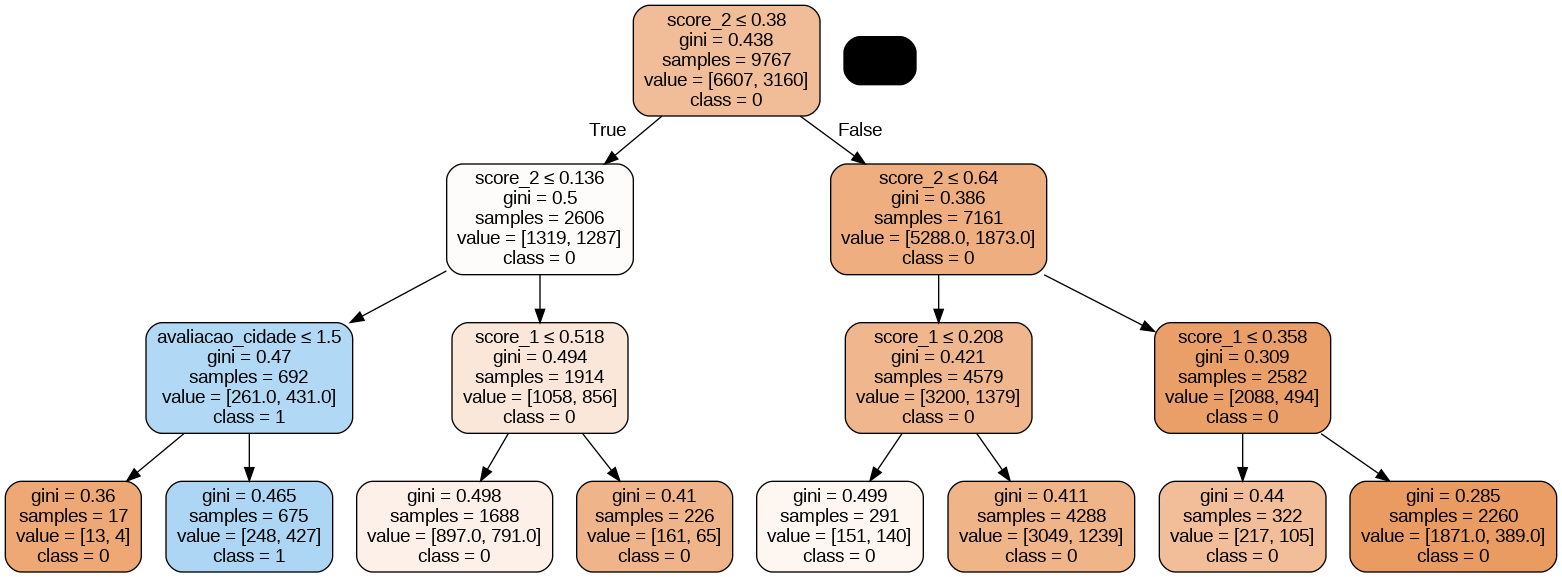

In [61]:
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

feature_cols = X_treino.columns
dot_data = StringIO()

export_graphviz(modelo_dt, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, feature_names = feature_cols, class_names=['0','1'])

graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

#### LogisticRegression

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [63]:
logistic_pipeline = make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE))
logistic_pipeline.fit(X_treino, y_treino)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(random_state=42))])

In [64]:
recall_lr = recall_score(y_teste, logistic_pipeline.predict(X_teste))
print(f'Recall do LR: {recall_lr:.3f}')

Recall do LR: 0.253


In [65]:
nome_colunas = list(X_treino.columns)
coef_model = logistic_pipeline.named_steps['logisticregression'].coef_[0]
coef_df = pd.DataFrame({"Coluna": nome_colunas, "coeficientes": coef_model})
coef_df.sort_values(by="coeficientes", ascending=False)

,Coluna,coeficientes
4,avaliacao_cidade,0.093488
2,anos_casa_propria,0.078257
1,anuidade_emprestimo,0.036625
0,receita_cliente,-0.012309
3,telefone_trab,-0.031449
8,score_social,-0.074919
9,troca_telefone,-0.097151
7,score_3,-0.149227
5,score_1,-0.250049
6,score_2,-0.464961


## Realizando busca em grade

### Busca em grade para o Decision Tree Classifier

In [66]:
from sklearn.model_selection import GridSearchCV

In [67]:
import numpy as np

param_grid_dt = {
    'criterion':  ['gini', 'entropy'],
    'max_depth': np.linspace(6, 12, 4, dtype=int),
    'min_samples_split': np.linspace(5, 20, 4, dtype=int),
    'min_samples_leaf': np.linspace(5, 20, 4, dtype=int),
    'max_features': ['sqrt', 'log2'],
    'splitter': ['best', 'random']
}

### Explicação dos Hiperparâmetros para `DecisionTreeClassifier`

- **`criterion`**: Este parâmetro define a função para medir a qualidade de uma divisão (split). As opções são:
    - `'gini'`: Mede a impureza de Gini. Uma impureza menor significa que o nó é mais 'puro', ou seja, contém predominantemente amostras de uma única classe.
    - `'entropy'`: Mede o ganho de informação com base na entropia. Uma entropia menor indica maior pureza. Ambos buscam criar nós homogêneos. Geralmente, `gini` é ligeiramente mais rápido de calcular.

- **`max_depth`**: Controla a profundidade máxima da árvore. Uma árvore mais profunda pode modelar relações mais complexas, mas é mais propensa ao *overfitting*. Um valor menor ajuda a generalizar melhor, mas pode levar ao *underfitting*. `np.linspace(6, 12, 4, dtype=int)` significa que serão testadas profundidades de 6, 8, 10 e 12.

- **`min_samples_split`**: O número mínimo de amostras que um nó deve ter para que possa ser dividido. Se um nó tiver menos amostras do que este valor, ele não será dividido, mesmo que isso possa melhorar a pureza. Valores mais altos impedem que o modelo aprenda relações muito específicas dos dados de treino, reduzindo o *overfitting*. `np.linspace(5, 20, 4, dtype=int)` testará 5, 10, 15 e 20 amostras.

- **`min_samples_leaf`**: O número mínimo de amostras que uma folha (nó terminal) deve ter. Uma divisão só será considerada se resultar em nós filhos com pelo menos este número de amostras em cada um. Isso ajuda a suavizar o modelo e evitar que a árvore crie nós muito pequenos que capturam ruído nos dados. `np.linspace(5, 20, 4, dtype=int)` testará 5, 10, 15 e 20 amostras por folha.

- **`max_features`**: O número de features a serem consideradas ao procurar a melhor divisão em cada nó. As opções são:
    - `'sqrt'`: Considera a raiz quadrada do número total de features (`sqrt(n_features)`).
    - `'log2'`: Considera o logaritmo base 2 do número total de features (`log2(n_features)`).
    Limitar o número de features ajuda a reduzir a variância e o *overfitting*, especialmente em conjuntos de dados com muitas features.

- **`splitter`**: A estratégia usada para escolher a divisão em cada nó. As opções são:
    - `'best'`: Escolhe a melhor divisão entre todas as features consideradas.
    - `'random'`: Escolhe a melhor divisão entre um subconjunto aleatório de features. `'random'` pode introduzir mais aleatoriedade e, às vezes, ajudar a reduzir o *overfitting* ou a encontrar soluções diferentes em rodadas de *cross-validation*.

In [68]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
             param_grid=param_grid_dt,
             scoring='recall',
             n_jobs=-1,
             cv=cv,
             )

dt_grid_search.fit(X_treino, y_treino)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': array([ 6,  8, 10, 12]),
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': array([ 5, 10, 15, 20]),
                         'min_samples_split': array([ 5, 10, 15, 20]),
                         'splitter': ['best', 'random']},
             scoring='recall')

### Obtendo informações da busca em grade

In [69]:
dt_grid_search.best_params_

{'criterion': 'gini',
 'max_depth': np.int64(12),
 'max_features': 'sqrt',
 'min_samples_leaf': np.int64(15),
 'min_samples_split': np.int64(5),
 'splitter': 'best'}

In [70]:
df_cv_results = pd.DataFrame(dt_grid_search.cv_results_)
df_cv_results.sort_values(by='rank_test_score')


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
246,0.027322,0.001663,0.006614,0.000264,gini,12,log2,15,20,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
244,0.026857,0.001060,0.007219,0.000441,gini,12,log2,15,15,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
242,0.027522,0.001975,0.007094,0.000419,gini,12,log2,15,10,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
240,0.027103,0.000912,0.007887,0.001473,gini,12,log2,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
214,0.027768,0.001822,0.007067,0.000572,gini,12,sqrt,15,20,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,0.011210,0.004632,0.010069,0.004460,entropy,8,log2,15,10,random,"{'criterion': 'entropy', 'max_depth': 8, 'max_...",0.167722,0.183544,0.102848,0.106013,0.156646,0.143354,0.032927,505
373,0.016303,0.007192,0.009821,0.002889,entropy,8,log2,15,15,random,"{'criterion': 'entropy', 'max_depth': 8, 'max_...",0.167722,0.183544,0.102848,0.106013,0.156646,0.143354,0.032927,505
375,0.017507,0.001254,0.012733,0.003487,entropy,8,log2,15,20,random,"{'criterion': 'entropy', 'max_depth': 8, 'max_...",0.167722,0.183544,0.102848,0.106013,0.156646,0.143354,0.032927,505
339,0.008149,0.000808,0.007320,0.002315,entropy,8,sqrt,15,10,random,"{'criterion': 'entropy', 'max_depth': 8, 'max_...",0.167722,0.183544,0.102848,0.106013,0.156646,0.143354,0.032927,505


In [71]:
df_cv_results.loc[[dt_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_features,param_min_samples_leaf,param_min_samples_split,param_splitter,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
208,0.028721,0.003117,0.008427,0.002212,gini,12,sqrt,15,5,best,"{'criterion': 'gini', 'max_depth': 12, 'max_fe...",0.242089,0.324367,0.272152,0.245253,0.232595,0.263291,0.033244,1


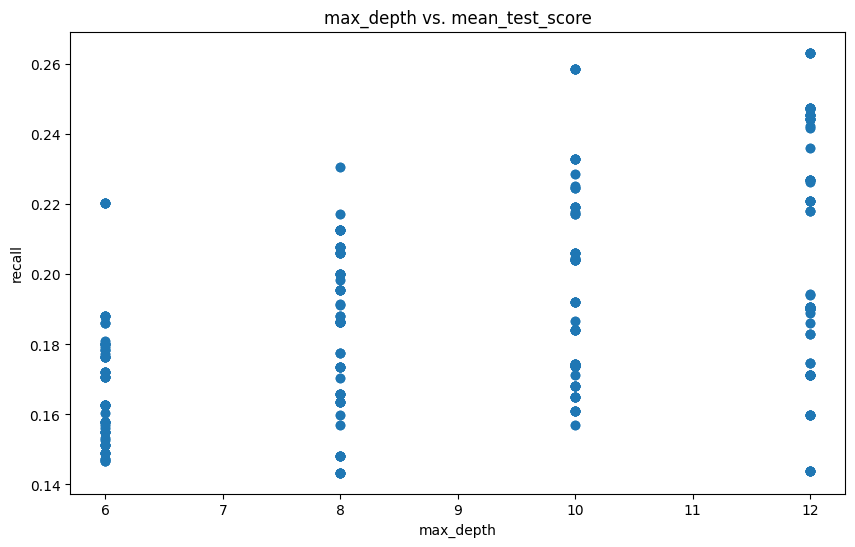

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(
    df_cv_results['param_max_depth'],
    df_cv_results['mean_test_score'],
    )

plt.title('max_depth vs. mean_test_score')
plt.xlabel('max_depth')
plt.ylabel('recall')
plt.show()

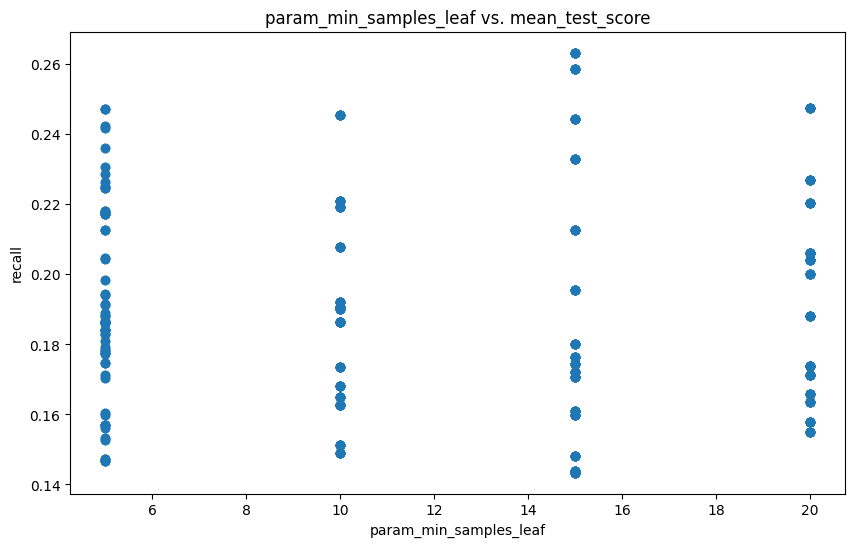

In [73]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df_cv_results['param_min_samples_leaf'],
    df_cv_results['mean_test_score'],
    )

plt.title('param_min_samples_leaf vs. mean_test_score')
plt.xlabel('param_min_samples_leaf')
plt.ylabel('recall')
plt.show()

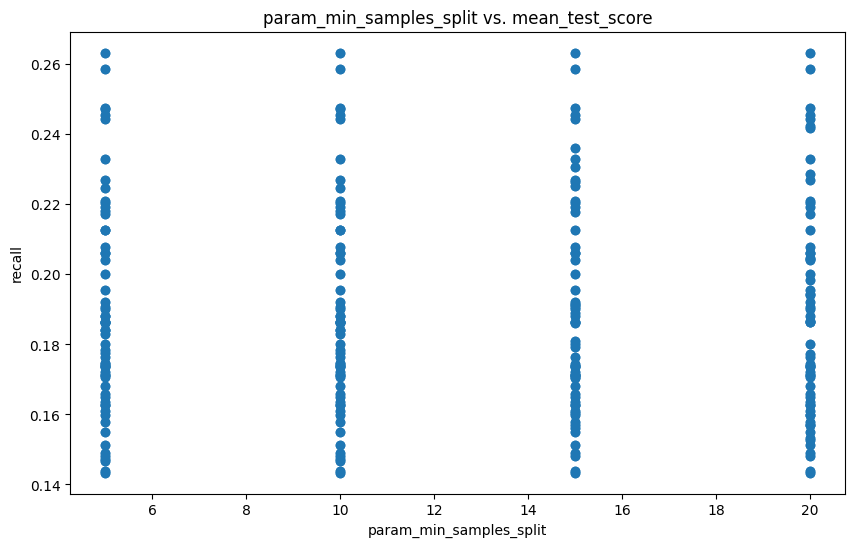

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(
    df_cv_results['param_min_samples_split'],
    df_cv_results['mean_test_score'],
    )

plt.title('param_min_samples_split vs. mean_test_score')
plt.xlabel('param_min_samples_split')
plt.ylabel('recall')
plt.show()

### Busca em grade para o LogisticRegression

In [75]:
max_iter = np.linspace(100, 300, 5, dtype=int)
c = [0.001, 0.01, 0.1, 1, 10]

param_grid_lr = [
    {'logisticregression__solver' : ['newton-cg', 'lbfgs'],
      'logisticregression__penalty' : ['l2'],
      'logisticregression__max_iter' : max_iter,
       'logisticregression__C' : c},
    {'logisticregression__solver' : ['liblinear'],
      'logisticregression__penalty' : ['l1', 'l2'],
      'logisticregression__max_iter' : max_iter,
      'logisticregression__C' : c},
]

### Explicação dos Hiperparâmetros para `LogisticRegression`

- **`logisticregression__max_iter`**: Este parâmetro define o número máximo de iterações que o algoritmo de otimização executará. Ele é usado para encontrar os coeficientes ideais do modelo. Se o modelo não convergir (atingir o critério de parada) antes de `max_iter` ser alcançado, o treinamento pode parar sem um resultado ideal. Valores maiores geralmente permitem que o modelo converja melhor, mas podem aumentar o tempo de treinamento. O `np.linspace(100, 300, 5, dtype=int)` significa que serão testados os valores 100, 150, 200, 250 e 300 para o número máximo de iterações.

- **`logisticregression__C`**: Este é o inverso da força de regularização. A regularização é uma técnica usada para evitar o *overfitting* penalizando coeficientes grandes. Valores menores de `C` significam uma regularização mais forte (o modelo se torna mais simples), enquanto valores maiores de `C` significam uma regularização mais fraca (o modelo tenta se ajustar mais aos dados de treinamento). O `[0.001, 0.01, 0.1, 1, 10]` indica que esses valores serão testados para `C`.

- **`logisticregression__solver`**: O algoritmo a ser usado na otimização. Diferentes *solvers* funcionam melhor com diferentes tipos de dados e penalidades. As opções testadas são:
    - `'newton-cg'`: Um método de otimização de segunda ordem. Bom para `l2` e não funciona com `l1`.
    - `'lbfgs'`: Um algoritmo da família quasi-Newton. É o *solver* padrão do scikit-learn e funciona bem com `l2`.
    - `'liblinear'`: Uma biblioteca para problemas de regressão linear e classificação linear. É eficiente para pequenos conjuntos de dados e suporta `l1` e `l2`.

- **`logisticregression__penalty`**: A norma usada na penalização. A penalização é aplicada para evitar o *overfitting*.
    - `'l1'` (Lasso): Adiciona o valor absoluto dos coeficientes como penalidade. Isso pode levar à esparsidade do modelo, ou seja, alguns coeficientes se tornam zero, efetivamente realizando seleção de features.
    - `'l2'` (Ridge): Adiciona o quadrado dos coeficientes como penalidade. Isso encolhe os coeficientes, mas raramente os torna zero. Ajuda a reduzir a complexidade do modelo e lidar com multicolinearidade.

In [76]:
lr_grid_search = GridSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
             param_grid=param_grid_lr,
             scoring='recall',
             n_jobs=-1,
             cv=cv,
             )

lr_grid_search.fit(X_treino, y_treino)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid=[{'logisticregression__C': [0.001, 0.01, 0.1, 1, 10],
                          'logisticregression__max_iter': array([100, 150, 200, 250, 300]),
                          'logisticregression__penalty': ['l2'],
                          'logisticregression__solver': ['newton-cg', 'lbfgs']},
                         {'logisticregression__C': [0.001, 0.01, 0.1, 1, 10],
                          'logisticregression__max_iter': array([100, 150, 200, 250, 300]),
                          'logisticregression__penalty': ['l1', 'l2'],
                          'logisticregression__solver': ['liblinear']}],
             scoring='recall')

In [77]:
lr_grid_search.best_params_

{'logisticregression__C': 0.001,
 'logisticregression__max_iter': np.int64(100),
 'logisticregression__penalty': 'l2',
 'logisticregression__solver': 'liblinear'}

In [78]:
lr_cv_results = pd.DataFrame(lr_grid_search.cv_results_)
lr_cv_results.sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
59,0.019781,0.000315,0.007894,0.000209,0.001,300,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1
53,0.028218,0.007182,0.012399,0.004279,0.001,150,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1
55,0.039756,0.011858,0.018776,0.007087,0.001,200,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1
51,0.023567,0.005514,0.010218,0.003716,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1
57,0.037914,0.005141,0.013693,0.003221,0.001,250,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1


In [79]:
lr_cv_results.loc[[lr_grid_search.best_index_]]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,param_logisticregression__max_iter,param_logisticregression__penalty,param_logisticregression__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
51,0.023567,0.005514,0.010218,0.003716,0.001,100,l2,liblinear,"{'logisticregression__C': 0.001, 'logisticregr...",0.251582,0.254747,0.265823,0.248418,0.235759,0.251266,0.009723,1


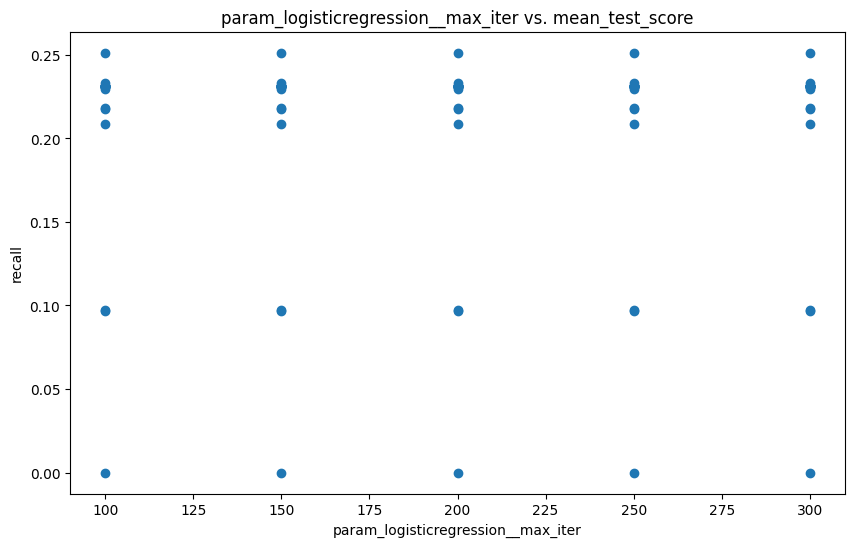

In [80]:
plt.figure(figsize=(10, 6))
plt.scatter(
    lr_cv_results['param_logisticregression__max_iter'],
    lr_cv_results['mean_test_score'],
    )

plt.title('param_logisticregression__max_iter vs. mean_test_score')
plt.xlabel('param_logisticregression__max_iter')
plt.ylabel('recall')
plt.show()

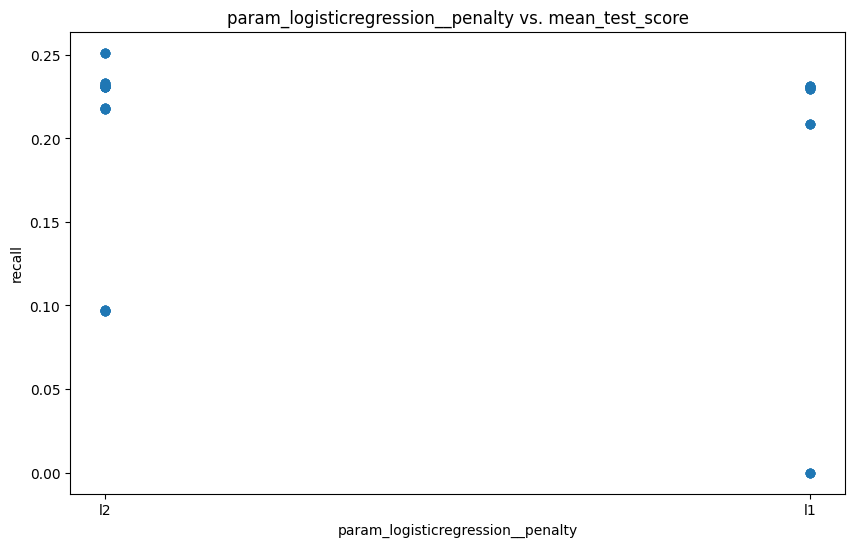

In [81]:
plt.figure(figsize=(10, 6))
plt.scatter(
    lr_cv_results['param_logisticregression__penalty'],
    lr_cv_results['mean_test_score'],
    )

plt.title('param_logisticregression__penalty vs. mean_test_score')
plt.xlabel('param_logisticregression__penalty')
plt.ylabel('recall')
plt.show()

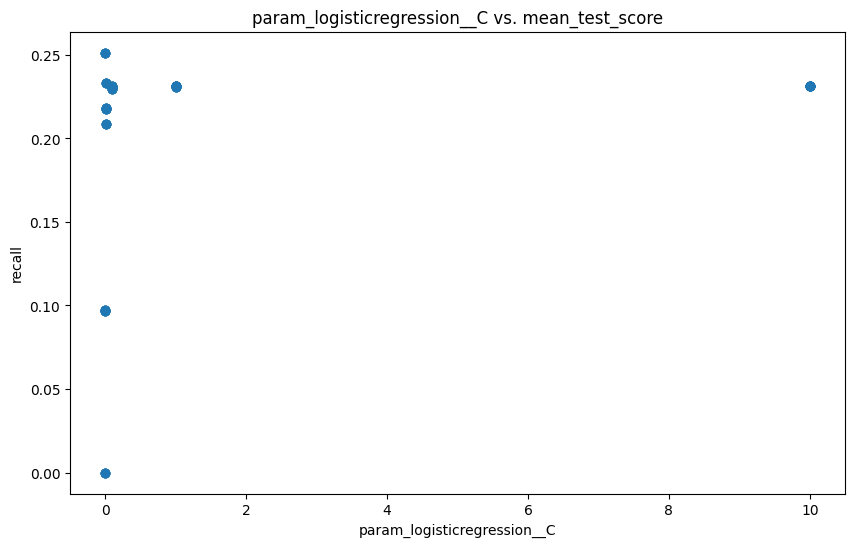

In [82]:
plt.figure(figsize=(10, 6))
plt.scatter(
    lr_cv_results['param_logisticregression__C'],
    lr_cv_results['mean_test_score'],
    )

plt.title('param_logisticregression__C vs. mean_test_score')
plt.xlabel('param_logisticregression__C')
plt.ylabel('recall')
plt.show()

### Busca em grade para o KNN (K-Nearest Neighbors)

In [83]:
param_grid_knn = {
    'n_neighbors': np.linspace(5, 25, 10, dtype=int),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

### Explicação dos Hiperparâmetros para `KNeighborsClassifier` (KNN)

- **`n_neighbors`**: Este é o número de vizinhos mais próximos a serem considerados na votação para prever a classe de um novo ponto. Um valor pequeno de `n_neighbors` torna o modelo mais sensível ao ruído (potencial para *overfitting*), enquanto um valor grande pode suavizar a fronteira de decisão, tornando-o menos sensível ao ruído, mas pode perder detalhes importantes nos dados (potencial para *underfitting*). `np.linspace(5, 25, 10, dtype=int)` significa que serão testados 10 valores inteiros igualmente espaçados entre 5 e 25, ou seja, 5, 7, 9, 11, 13, 16, 18, 20, 22 e 25.

- **`weights`**: Este parâmetro define como os votos dos vizinhos são ponderados. As opções são:
    - `'uniform'`: Todos os pontos em uma vizinhança recebem peso igual. A previsão é feita pela maioria simples dos votos dos vizinhos.
    - `'distance'`: Os pontos mais próximos têm maior influência na previsão. O peso de cada vizinho é inversamente proporcional à sua distância do ponto de consulta. Isso pode ser útil quando há vizinhos a diferentes distâncias e queremos dar mais importância aos mais próximos.

- **`metric`**: A função de distância usada para calcular a distância entre os pontos e encontrar os vizinhos mais próximos. As opções comuns são:
    - `'euclidean'`: A distância euclidiana, que é a distância em linha reta entre dois pontos no espaço. É a métrica mais comum e padrão.
    - `'manhattan'`: A distância de Manhattan (ou 'city block distance'), que é a soma das diferenças absolutas de suas coordenadas. É como a distância que um carro percorreria em um grid de ruas de cidade.

In [84]:
from sklearn.neighbors import KNeighborsClassifier

knn_grid_search = GridSearchCV(estimator = KNeighborsClassifier(),
             param_grid=param_grid_knn,
             scoring='recall',
             n_jobs=-1,
             cv=cv,
             )

knn_grid_search.fit(X_treino, y_treino)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': array([ 5,  7,  9, 11, 13, 16, 18, 20, 22, 25]),
                         'weights': ['uniform', 'distance']},
             scoring='recall')

In [85]:
knn_grid_search.best_params_

{'metric': 'manhattan', 'n_neighbors': np.int64(5), 'weights': 'distance'}

In [86]:
knn_cv_results = pd.DataFrame(knn_grid_search.cv_results_)
knn_cv_results.sort_values(by='rank_test_score').head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_metric,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
21,0.025256,0.006101,0.053847,0.011401,manhattan,5,distance,"{'metric': 'manhattan', 'n_neighbors': 5, 'wei...",0.297468,0.272152,0.268987,0.286392,0.275316,0.280063,0.010496,1
1,0.023178,0.002241,0.040883,0.001834,euclidean,5,distance,"{'metric': 'euclidean', 'n_neighbors': 5, 'wei...",0.291139,0.268987,0.262658,0.287975,0.272152,0.276582,0.011071,2
23,0.021920,0.000274,0.052035,0.003221,manhattan,7,distance,"{'metric': 'manhattan', 'n_neighbors': 7, 'wei...",0.283228,0.254747,0.240506,0.261076,0.257911,0.259494,0.013794,3
3,0.022825,0.000429,0.044985,0.002062,euclidean,7,distance,"{'metric': 'euclidean', 'n_neighbors': 7, 'wei...",0.264241,0.257911,0.253165,0.261076,0.261076,0.259494,0.003744,3
5,0.022579,0.000237,0.046559,0.001314,euclidean,9,distance,"{'metric': 'euclidean', 'n_neighbors': 9, 'wei...",0.257911,0.227848,0.232595,0.248418,0.240506,0.241456,0.010806,5


## validação cruzada aninhada

### Como funciona a validação cruzada aninhada

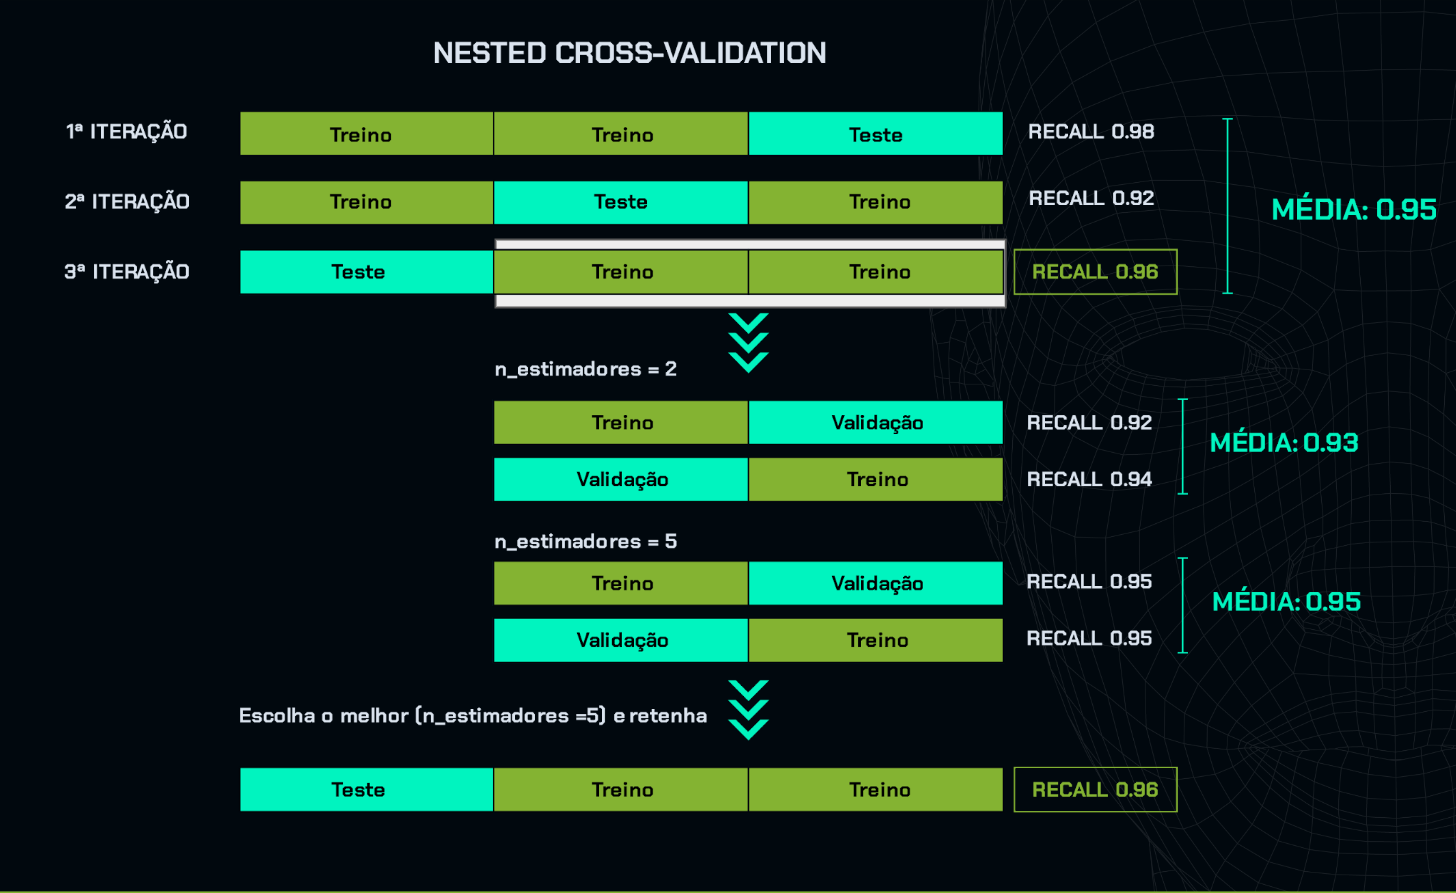

**Validação Cruzada Simples (GridSearchCV)**: Ótimo para encontrar os melhores hiperparâmetros e ter uma ideia do desempenho, mas a estimativa final pode ser um pouco otimista.


**Validação Cruzada Aninhada:** Fornece uma estimativa mais honesta e robusta do desempenho generalizado do modelo, pois os dados de teste finais são completamente separados do processo de otimização de hiperparâmetros. É mais custoso computacionalmente, mas vale a pena quando uma estimativa precisa do desempenho é crucial.


### Validação cruzada aninhada no Decision Tree Classifier

In [87]:
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [88]:
from sklearn.model_selection import cross_val_score

dt_nested_gs = GridSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
             param_grid=param_grid_dt,
             scoring='recall',
             n_jobs=-1,
             cv=inner_cv,
             )

dt_nested_scores = cross_val_score(dt_nested_gs, X_treino, y_treino, scoring='recall', cv=outer_cv)

In [89]:
print(f'resultado de cada iteração do cv externo: {dt_nested_scores}')
print(f'média dos resultados: {np.mean(dt_nested_scores)}')

resultado de cada iteração do cv externo: [0.23646724 0.24762808 0.20512821]
média dos resultados: 0.2297411750289676



### Validação cruzada aninhada no Logistic Regression

In [90]:
lr_nestde_gs = GridSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression(random_state=RANDOM_STATE)),
             param_grid=param_grid_lr,
             scoring='recall',
             n_jobs=-1,
             cv=inner_cv,
             )

lr_nested_scores = cross_val_score(lr_nestde_gs, X_treino, y_treino, scoring='recall', cv=outer_cv)

In [91]:
print(f'resultado de cada iteração do cv externo: {lr_nested_scores}')
print(f'média dos resultados: {np.mean(lr_nested_scores)}')

resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
média dos resultados: 0.2537901108426093


## Busca aleatória

### Busca aleatória para o Decision Tree Classifier

In [92]:
from sklearn.model_selection import RandomizedSearchCV

In [93]:
rs_dt = RandomizedSearchCV(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            param_distributions=param_grid_dt,
            n_iter=100,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=RANDOM_STATE)

rs_dt_nested_score = cross_val_score(rs_dt, X_treino, y_treino, cv=outer_cv)

In [94]:
print(f'resultado de cada iteração do cv externo: {rs_dt_nested_score}')
print(f'média dos resultados: {np.mean(rs_dt_nested_score)}')

resultado de cada iteração do cv externo: [0.23646724 0.18975332 0.21272555]
média dos resultados: 0.21298203440307595


In [95]:
rs_dt.fit(X_treino, y_treino)
rs_dt.best_params_

{'splitter': 'best',
 'min_samples_split': np.int64(5),
 'min_samples_leaf': np.int64(15),
 'max_features': 'sqrt',
 'max_depth': np.int64(12),
 'criterion': 'gini'}

### Busca aleatória para o LogisticRegression

In [96]:
rs_lr = RandomizedSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression()),
            param_distributions=param_grid_lr,
            n_iter=50,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=RANDOM_STATE)

rs_lr_nested_score = cross_val_score(rs_lr, X_treino, y_treino, cv=outer_cv)

print(f'resultado de cada iteração do cv externo: {rs_lr_nested_score}')
print(f'média dos resultados: {np.mean(rs_lr_nested_score)}')

resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
média dos resultados: 0.2537901108426093


In [97]:
rs_lr.fit(X_treino, y_treino)
rs_lr.best_params_

{'logisticregression__solver': 'liblinear',
 'logisticregression__penalty': 'l2',
 'logisticregression__max_iter': np.int64(150),
 'logisticregression__C': 0.001}

## Otimização bayesiana

### Otimização bayesiana para o Decision Tree Classifier

In [98]:
!pip install scikit-optimize

In [99]:
from skopt.space import Real, Integer, Categorical

space_dt = {
    'criterion': Categorical(['gini', 'entropy']),
    'max_depth': Integer(6, 12),
    'min_samples_split': Integer(5, 20),
    'min_samples_leaf': Integer(5, 20),
    'max_features': Categorical(['sqrt', 'log2']),
    'splitter': Categorical(['best', 'random'])
}

In [100]:
from skopt import BayesSearchCV

In [101]:
opt_dt = BayesSearchCV(estimator= DecisionTreeClassifier(random_state=RANDOM_STATE),
                    search_spaces = space_dt,
                    n_iter=50,
                    scoring='recall',
                    n_jobs=-1,
                    cv=inner_cv,
                    random_state=RANDOM_STATE,
                    error_score='raise',
                    return_train_score=False)

bs_dt_nested_scores = cross_val_score(opt_dt, X_treino, y_treino, cv=outer_cv)

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(11), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['entropy', np.int64(11), 'log2', np.int64(16), np.int64(16), 'best']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('entropy'), np.int64(12), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['gini', np.int64(6), 'log2', np.int64(8), np.int64(15), 'best']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('gini'), np.int64(12), np.str_('log2'), np.int64(20), np.int64(5), np.str_('best')] before, using random point ['entropy', np.int64(11), 'log2', np.int64(16), np.int64(17), 'best']
  warnings.

In [102]:

print(f'resultado de cada iteração do cv externo: {bs_dt_nested_scores}')
print(f'média dos resultados: {np.mean(bs_dt_nested_scores)}')

resultado de cada iteração do cv externo: [0.23931624 0.31973435 0.21272555]
média dos resultados: 0.2572587102420541


In [103]:
opt_dt.fit(X_treino, y_treino)


BayesSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
              estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
              random_state=42, scoring='recall',
              search_spaces={'criterion': Categorical(categories=('gini', 'entropy'), prior=None),
                             'max_depth': Integer(low=6, high=12, prior='uniform', transform='normalize'),
                             'max_features': Categorical(categories=('sqrt', 'log2'), prior=None),
                             'min_samples_leaf': Integer(low=5, high=20, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=5, high=20, prior='uniform', transform='normalize'),
                             'splitter': Categorical(categories=('best', 'random'), prior=None)})

In [104]:
opt_dt.best_params_

OrderedDict([('criterion', 'gini'),
             ('max_depth', 12),
             ('max_features', 'log2'),
             ('min_samples_leaf', 15),
             ('min_samples_split', 5),
             ('splitter', 'best')])

### Otimização bayesiana para o LogisticRegression

In [107]:
max_iter = Integer(100, 300)
c = Categorical([0.001, 0.01, 0.1, 1, 10])

space_lr = [
    {
        'logisticregression__solver': Categorical(['newton-cg', 'lbfgs']),
        'logisticregression__penalty': Categorical(['l2']),
        'logisticregression__max_iter': max_iter,
        'logisticregression__C': c
    },
    {
        'logisticregression__solver': Categorical(['liblinear']),
        'logisticregression__penalty': Categorical(['l1', 'l2']),
        'logisticregression__max_iter': max_iter,
        'logisticregression__C': c
    },
]

In [108]:
opt_lr = BayesSearchCV(estimator=make_pipeline(StandardScaler(), LogisticRegression()),
            search_spaces = space_lr,
            n_iter=50,
            scoring='recall',
            n_jobs=-1,
            cv=inner_cv,
            random_state=RANDOM_STATE)

bs_lr_nested_scores = cross_val_score(opt_lr, X_treino, y_treino, cv=outer_cv)

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(134), np.str_('l2'), np.str_('lbfgs')] before, using random point [0.001, np.int64(217), 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(134), np.str_('l2'), np.str_('lbfgs')] before, using random point [0.001, np.int64(217), 'l2', 'lbfgs']
  warnings.warn(


In [109]:
print(f'resultado de cada iteração do cv externo: {bs_lr_nested_scores}')
print(f'média: {bs_lr_nested_scores.mean()}')

resultado de cada iteração do cv externo: [0.24691358 0.27703985 0.2374169 ]
média: 0.2537901108426093


In [111]:
opt_lr.fit(X_treino, y_treino)
opt_lr.best_params_

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(10), np.int64(134), np.str_('l2'), np.str_('lbfgs')] before, using random point [0.001, np.int64(217), 'l2', 'lbfgs']
  warnings.warn(


OrderedDict([('logisticregression__C', 0.001),
             ('logisticregression__max_iter', 150),
             ('logisticregression__penalty', 'l2'),
             ('logisticregression__solver', 'liblinear')])

In [112]:
opt_lr.predict(X_teste)

array([0, 1, 0, ..., 0, 0, 0])